In [ ]:
1. Import Libraries

In [29]:
# pandas - works with data tables 
import pandas as pd
# numpy - math and working with lists 
import numpy as np
# train_test_split helps divide data
from sklearn.model_selection import train_test_split
# LabelEncoder helps turn words into numbers
from sklearn.preprocessing import LabelEncoder
# accuracy_score and others help check how good the model is
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# These are tools from the pgmpy library for Bayesian Networks
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
# To plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
# To ignore some warnings that might pop up but aren't critical
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

2. Load the Dataset

In [30]:
try:
    df = pd.read_csv('weatherAUS.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Could not find the dataset file.")

Dataset loaded successfully!


3. Explore the Data

In [31]:
# Show the first 5 rows
print("\nFirst 5 rows of the data:")
print(df.head())

# Get info about columns and missing values
print("\nInformation about the columns:")
df.info()


First 5 rows of the data:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  Rain

4. Prepare the Data for the Bayesian Network

In [32]:
# We need to clean the data and make it suitable for the model.

# Step 4a: Select Relevant Columns
# Let's pick a few columns that might predict rain tomorrow.
# We choose some weather measurements around 3pm, plus RainToday and RainTomorrow.
cols_to_keep = ['Humidity3pm', 'Pressure3pm', 'Cloud3pm', 'WindGustSpeed', 'RainToday', 'RainTomorrow']
df_selected = df[cols_to_keep].copy() # Use .copy() to avoid warnings
print(f"\nSelected columns: {cols_to_keep}")

# Step 4b: Handle Missing Values
# We need to fill in the blanks or remove rows with missing info.

# Drop rows where our target 'RainTomorrow' is missing as we need this answer.
df_selected.dropna(subset=['RainTomorrow'], inplace=True)
print(f"Removed rows with missing RainTomorrow. New shape: {df_selected.shape}")

# Also drop rows where 'RainToday' is missing as we use it as a predictor.
df_selected.dropna(subset=['RainToday'], inplace=True)
print(f"Removed rows with missing RainToday. New shape: {df_selected.shape}")

# For the number columns fill missing values (NaN) with the median.
# Median is often better than mean if there are very high or low outlier numbers.
num_cols = ['Humidity3pm', 'Pressure3pm', 'Cloud3pm', 'WindGustSpeed']
for col in num_cols:
    # Calculate the median value for the column
    median_val = df_selected[col].median()
    # Fill missing values in that column with the median
    df_selected[col].fillna(median_val, inplace=True)
    print(f"Filled missing values in '{col}' with median ({median_val}).")

# Check again for missing values to be sure
print("\nMissing values after handling:")
print(df_selected.isnull().sum())

# Step 4c: Convert 'Yes'/'No' to Numbers (0/1)
# Change RainToday and RainTomorrow from words to numbers.
df_selected['RainToday'] = df_selected['RainToday'].map({'No': 0, 'Yes': 1})
df_selected['RainTomorrow'] = df_selected['RainTomorrow'].map({'No': 0, 'Yes': 1})
print("\nConverted RainToday and RainTomorrow to 0s and 1s.")

# Step 4d: Discretize Continuous Variables 
# Bayesian Networks often work better with categories. Let's group the number columns.
# We'll cut Humidity, Pressure, Cloud, and WindSpeed into 3 bins: Low, Medium, High.
# 'pd.qcut' tries to put roughly the same number of data points in each bin.

# Define the number of bins (categories)
n_bins = 3
# Define labels for the bins
bin_labels = ['Low', 'Medium', 'High']

# Loop through the columns we want to discretize
for col in num_cols:
    try:
        # Cut the data into bins based on quantiles (equal number of points per bin)
        # include_lowest=True makes sure the smallest value is included in the first bin
        # duplicates='drop' handles cases where bin edges might be the same value
        df_selected[col] = pd.qcut(df_selected[col], q=n_bins, labels=bin_labels, duplicates='drop')
        print(f"Discretized '{col}' into {n_bins} bins.")
    except ValueError as e:
        # If qcut fails (maybe too many identical values), print an error and keep the column as numbers for now
        print(f"Could not discretize '{col}' using qcut due to error: {e}. Keeping as continuous (this might affect BN).")
        # As a fallback, maybe try cutting into fewer bins or using pd.cut with fixed edges if qcut fails consistently.
        # For simplicity here, we'll just report the issue.

# Show the first few rows with the changes
print("\nFirst 5 rows after discretization:")
print(df_selected.head())

# Check the value counts for a discretized column to see the bins
print("\nValue counts for discretized Humidity3pm:")
print(df_selected['Humidity3pm'].value_counts())

# Check data types again - discretized columns should now be 'category'
print("\nColumn types after preparation:")
df_selected.info()


Selected columns: ['Humidity3pm', 'Pressure3pm', 'Cloud3pm', 'WindGustSpeed', 'RainToday', 'RainTomorrow']
Removed rows with missing RainTomorrow. New shape: (142193, 6)
Removed rows with missing RainToday. New shape: (140787, 6)
Filled missing values in 'Humidity3pm' with median (52.0).
Filled missing values in 'Pressure3pm' with median (1015.2).
Filled missing values in 'Cloud3pm' with median (5.0).
Filled missing values in 'WindGustSpeed' with median (39.0).

Missing values after handling:
Humidity3pm      0
Pressure3pm      0
Cloud3pm         0
WindGustSpeed    0
RainToday        0
RainTomorrow     0
dtype: int64

Converted RainToday and RainTomorrow to 0s and 1s.
Discretized 'Humidity3pm' into 3 bins.
Discretized 'Pressure3pm' into 3 bins.
Could not discretize 'Cloud3pm' using qcut due to error: Bin labels must be one fewer than the number of bin edges. Keeping as continuous (this might affect BN).
Discretized 'WindGustSpeed' into 3 bins.

First 5 rows after discretization:
  Hum

5. Split Data into Training and Testing Sets

In [33]:
# Divide data for learning and testing.

# Define features (X) and target (y) from our prepared data
y = df_selected['RainTomorrow']
X = df_selected.drop('RainTomorrow', axis=1)

# Split the data, using 80% for training, 20% for testing
# stratify helps keep the proportion of rain/no rain similar in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Combine X_train and y_train back together for fitting the BN model, as pgmpy often takes the full dataframe
train_data = pd.concat([X_train, y_train], axis=1)
# Keep X_test and y_test separate for prediction and evaluation
test_data_features = X_test
test_data_actual = y_test

print(f"\nNumber of rows in training set: {train_data.shape[0]}")
print(f"Number of rows in test set: {test_data_features.shape[0]}")


Number of rows in training set: 112629
Number of rows in test set: 28158


6. Define the Bayesian Network Structure

In [34]:
# Tell the model how the weather factors are related (which arrows to draw).

# We define the relationships (edges) as a list of tuples.
# Format: (Source Node, Target Node)
# Example: ('Humidity3pm', 'RainTomorrow') means Humidity affects RainTomorrow.
# These are based on our assumptions from H1.
model_structure = [
    ('Pressure3pm', 'Humidity3pm'),
    ('WindGustSpeed', 'Cloud3pm'),
    ('Humidity3pm', 'RainTomorrow'),
    ('Cloud3pm', 'RainTomorrow'),
    ('RainToday', 'RainTomorrow')
]

# Create a BayesianNetwork object with our defined structure
bn_model = DiscreteBayesianNetwork(model_structure)
print("\nDefined Bayesian Network structure.")


Defined Bayesian Network structure.


7. Train the Bayesian Network (Learn Probabilities)

In [35]:
# Calculate the probability tables (CPTs) from the training data.

# We use Maximum Likelihood Estimation to learn the probabilities.
# This finds the probabilities that best match the patterns seen in the training data.
# state_names argument helps if columns are categorical with specific labels.
# It seems pgmpy handles string categories well here.
bn_model.fit(train_data, estimator=MaximumLikelihoodEstimator)
print("Model training (parameter learning) complete.")

# Let's look at one of the learned probability tables (CPTs)
# For example, the CPT for RainTomorrow
try:
    cpt_rain_tomorrow = bn_model.get_cpds('RainTomorrow')
    print("\nLearned CPT for RainTomorrow (showing part of it):")
    # CPTs can be large, just print the object representation
    print(cpt_rain_tomorrow)
except Exception as e:
    print(f"Could not display CPT for RainTomorrow: {e}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Humidity3pm': 'O', 'Pressure3pm': 'O', 'Cloud3pm': 'N', 'WindGustSpeed': 'O', 'RainToday': 'N', 'RainTomorrow': 'N'}


Model training (parameter learning) complete.

Learned CPT for RainTomorrow (showing part of it):
+-----------------+-----+---------------------+
| Cloud3pm        | ... | Cloud3pm(9.0)       |
+-----------------+-----+---------------------+
| Humidity3pm     | ... | Humidity3pm(Medium) |
+-----------------+-----+---------------------+
| RainToday       | ... | RainToday(1)        |
+-----------------+-----+---------------------+
| RainTomorrow(0) | ... | 0.5                 |
+-----------------+-----+---------------------+
| RainTomorrow(1) | ... | 0.5                 |
+-----------------+-----+---------------------+


8. Make Predictions on the Test Set

In [36]:
# Use the trained model to predict the chance of rain for the test data.

# Prepare the model for making predictions (inference)
inference = VariableElimination(bn_model)
print("\nPrepared model for inference.")

# Get the feature names from the test data (excluding the actual answer)
feature_columns = test_data_features.columns.tolist()

# Make predictions row by row for the test set
# We predict the probability of RainTomorrow=1 (meaning 'Yes' for rain)
predicted_probabilities = []
predictions_binary = [] # Store 0/1 predictions based on threshold
probability_threshold = 0.5 # If probability > 0.5, predict rain (1)

# Loop through each row in the test data features
for index, row in test_data_features.iterrows():
    try:
        # Create a dictionary of the evidence for this row
        evidence_dict = row.to_dict()
        # Query the model for the probability distribution of RainTomorrow given the evidence
        result = inference.query(variables=['RainTomorrow'], evidence=evidence_dict)
        # Get the probability specifically for RainTomorrow = 1 (Yes)
        prob_rain = result.values[1] # Assumes state 1 corresponds to 'Yes'/1
        predicted_probabilities.append(prob_rain)
        # Convert probability to binary prediction (0 or 1)
        predictions_binary.append(1 if prob_rain > probability_threshold else 0)

    except Exception as e:
        # If prediction fails for a row, record NaN or a default value and print error
        print(f"Error predicting for row {index}: {e}")
        predicted_probabilities.append(np.nan)
        predictions_binary.append(np.nan) # Or choose a default like 0

print(f"Made predictions for {len(predictions_binary)} test samples.")

# Convert the list of binary predictions to a numpy array for evaluation
# We need to handle potential NaN values if any rows failed prediction
predictions_binary = np.array(predictions_binary)
# Create a mask to filter out rows where prediction failed
valid_prediction_mask = ~np.isnan(predictions_binary)


Prepared model for inference.
Made predictions for 28158 test samples.


9. Evaluate the Model's Performance


Model Accuracy on Test Set (valid predictions): 0.8133

Classification Report (valid predictions):
              precision    recall  f1-score   support

           0       0.85      0.92      0.88     21918
           1       0.61      0.44      0.51      6240

    accuracy                           0.81     28158
   macro avg       0.73      0.68      0.70     28158
weighted avg       0.80      0.81      0.80     28158


Confusion Matrix (valid predictions):
[[20163  1755]
 [ 3502  2738]]


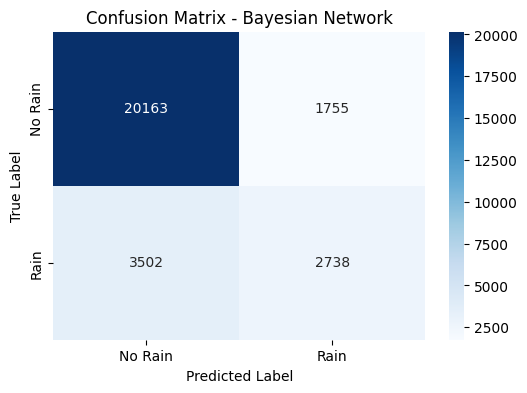

In [37]:
# Compare the model's predictions to the actual answers.

# Filter both actual and predicted values to only include valid predictions
y_test_filtered = test_data_actual[valid_prediction_mask]
y_pred_filtered = predictions_binary[valid_prediction_mask].astype(int) # Ensure integer type

# Calculate accuracy only on the successfully predicted rows
accuracy = accuracy_score(y_test_filtered, y_pred_filtered)
print(f"\nModel Accuracy on Test Set (valid predictions): {accuracy:.4f}")

# Print the classification report
print("\nClassification Report (valid predictions):")
print(classification_report(y_test_filtered, y_pred_filtered))

# Show the confusion matrix
print("\nConfusion Matrix (valid predictions):")
cm = confusion_matrix(y_test_filtered, y_pred_filtered)
print(cm)
#TODO
# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Bayesian Network')
plt.show()